# 🧠 Diffusion Small Language Model (dSLM) — TransformerUNet from Scratch

## What is a Diffusion Language Model?

Unlike autoregressive LLMs (GPT-style) that generate text **token-by-token left to right**, a **Diffusion Language Model (dLM)** works through two phases:

- **Forward process**: Corrupt clean text by progressively masking tokens (`[MASK]` tokens replace real tokens at rate `t`)
- **Reverse process**: Learn to **denoise** — predict all masked tokens simultaneously from noisy input

This enables **parallel generation**, **bidirectional context**, and **iterative refinement**.

### Key papers:
- **MDLM** (Masked Diffusion Language Model) — the foundation
- **LLaDA** (2025) — 8B param dLM competitive with LLaMA3 8B
- **SEDD** (ICML 2024 Best Paper) — score entropy discrete diffusion

## Architecture: TransformerUNet

We adapt the UNet design from image diffusion (encoder→bottleneck→decoder with skip connections) to **1D token sequences**:

```
Input tokens → [Embed + Time embed]
    ↓
Encoder: [TransformerBlock × L] → downsample (stride conv)
    ↓
Bottleneck: [TransformerBlock × L_mid]
    ↓
Decoder: [TransformerBlock × L] + skip connections → upsample
    ↓
Output: logits over vocab
```

**Why UNet for text?**
- Skip connections preserve fine-grained token-level info at multiple scales
- Multi-scale representation: local syntax (early layers) ↔ global semantics (bottleneck)
- Analogous to how DDPM UNet captures image details at multiple resolutions

## 1. Setup & Imports

In [1]:
# Install dependencies
!pip install torch transformers datasets einops tqdm matplotlib datasets

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, repeat
from transformers import AutoTokenizer
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Hyperparameters & Config

In [3]:
class Config:
    tokenizer_name  = 'gpt2'
    vocab_size      = 50257
    mask_token_id   = 50256

    seq_len         = 128
    d_model         = 256
    n_heads         = 8
    d_ff            = 1024
    dropout         = 0.1

    encoder_layers    = [2, 2, 2]
    bottleneck_layers = 4
    decoder_layers    = [2, 2, 2]

    T               = 1000
    batch_size      = 32
    lr              = 2e-4
    n_epochs        = 30
    max_steps       = 30_000
    grad_clip       = 1.0
    warmup_steps    = 500
    n_steps_inf     = 50

cfg = Config()
print('Config loaded.')

Config loaded.


```markdown

╔══════════════════════════════════════════════════════════════════════════╗
║              TRANSFORMER UNET — DIFFUSION LANGUAGE MODEL                 ║
║                     Forward Pass  (B, L) → (B, L, V)                     ║
╚══════════════════════════════════════════════════════════════════════════╝

  INPUT
  ─────
  x_t  (B, L)   noisy token ids at timestep t
  t    (B,)     diffusion timestep  [1 … T]

  ┌─────────────────────────────────────────────────────────────────────┐
  │  EMBEDDING LAYER                                                    │
  │                                                                     │
  │   x_t ──► TokenEmbed(V→D)  ──┐                                      │
  │                              ├──► ADD ──► Dropout ──► x  (B,L,D)    │
  │   pos ──► PosEmbed(L→D)    ──┘                                      │
  │                                                                     │
  │   t   ──► SinusoidalEmbed ──► MLP(D→4D→D) ──► time_emb  (B,D)       │
  └─────────────────────────────────────────────────────────────────────┘
                          │                  │
                          │ x (B,L,D)        │ time_emb (B,D)
                          │                  │  (broadcast to every block)
                          ▼                  ▼
  ╔═════════════════════════════════════════════════════╗
  ║  ENCODER                                            ║   skip connections
  ║                                                     ║   saved here (↓)
  ║  Scale 0   L=128, D=256                             ║
  ║  ┌─────────────────────────────────────────────┐    ║
  ║  │  TransformerBlock × 2                       │    ║
  ║  │  ┌──────────────────────────────────────┐   │    ║
  ║  │  │  AdaLN(x, time_emb)                  │   │    ║
  ║  │  │    scale,shift = Linear(D → 2D)(t_e) │   │    ║
  ║  │  │    x̂ = LN(x) * (1+scale) + shift     │   │    ║
  ║  │  │  MultiHeadSelfAttention(H=8)         │   │    ║
  ║  │  │  x = x + Attn(x̂)                     │   │    ║
  ║  │  │  x = x + FFN(LN(x))  [D→4D→D, GELU]  │   │    ║
  ║  │  └──────────────────────────────────────┘   │    ║
  ║  └─────────────────────────────────────────────┘    ║
  ║          │  skip_0  (B, 128, D)   ──────────────────╬──────────────┐
  ║          ▼                                          ║              │
  ║  Downsample: Conv1D(stride=2) + LN                  ║              │
  ║          │  (B, 64, D)                              ║              │
  ║          ▼                                          ║              │
  ║  Scale 1   L=64, D=256                              ║              │
  ║  ┌─────────────────────────────────────────────┐    ║              │
  ║  │  TransformerBlock × 2                       │    ║              │
  ║  └─────────────────────────────────────────────┘    ║              │
  ║          │  skip_1  (B, 64, D)    ──────────────────╬──────────┐   │
  ║          ▼                                          ║          │   │
  ║  Downsample: Conv1D(stride=2) + LN                  ║          │   │
  ║          │  (B, 32, D)                              ║          │   │
  ║          ▼                                          ║          │   │
  ║  Scale 2   L=32, D=256                              ║          │   │
  ║  ┌─────────────────────────────────────────────┐    ║          │   │
  ║  │  TransformerBlock × 2                       │    ║          │   │
  ║  └─────────────────────────────────────────────┘    ║          │   │
  ║          │  skip_2  (B, 32, D)    ──────────────────╬──────┐   │   │
  ╚══════════╪══════════════════════════════════════════╝      │   │   │
             │  (B, 32, D)                                     │   │   │
             ▼                                                 │   │   │
  ╔══════════════════════════════════╗                         │   │   │
  ║  BOTTLENECK   L=32, D=256        ║                         │   │   │
  ║                                  ║                         │   │   │
  ║  TransformerBlock × 4            ║                         │   │   │
  ║  (deepest global context)        ║                         │   │   │
  ╚══════════╪═══════════════════════╝                         │   │   │
             │  (B, 32, D)                                     │   │   │
             ▼                                                 │   │   │
  ╔═════════════════════════════════════════════════╗          │   │   │
  ║  DECODER                                        ║          │   │   │
  ║                                                 ║          │   │   │
  ║  Scale 0  (mirror of Enc Scale 2)   L=32        ║          │   │   │
  ║  ┌──────────────────────────────────────────┐   ║          │   │   │
  ║  │  GatedSkipFusion                         │◄──╬──────────┘   │   │
  ║  │    gate = sigmoid(α)                     │   ║  skip_2      │   │
  ║  │    fused = gate*skip + (1-gate)*x_up     │   ║              │   │
  ║  │    out = Linear(2D→D)(cat[x_up, fused])  │   ║              │   │
  ║  │  TransformerBlock × 2                    │   ║              │   │
  ║  └──────────────────────────────────────────┘   ║              │   │
  ║          │  (B, 32, D)                          ║              │   │
  ║          ▼                                      ║              │   │
  ║  Upsample: Interpolate(×2) + Conv1D + LN        ║              │   │
  ║          │  (B, 64, D)                          ║              │   │
  ║          ▼                                      ║              │   │
  ║  Scale 1  (mirror of Enc Scale 1)   L=64        ║              │   │
  ║  ┌──────────────────────────────────────────┐   ║              │   │
  ║  │  GatedSkipFusion                         │◄──╬──────────────┘   │
  ║  │  TransformerBlock × 2                    │   ║  skip_1          │
  ║  └──────────────────────────────────────────┘   ║                  │
  ║          │  (B, 64, D)                          ║                  │
  ║          ▼                                      ║                  │
  ║  Upsample: Interpolate(×2) + Conv1D + LN        ║                  │
  ║          │  (B, 128, D)                         ║                  │
  ║          ▼                                      ║                  │
  ║  Scale 2  (mirror of Enc Scale 0)   L=128       ║                  │
  ║  ┌──────────────────────────────────────────┐   ║                  │
  ║  │  GatedSkipFusion                         │◄──╬──────────────────┘
  ║  │  TransformerBlock × 2                    │   ║  skip_0
  ║  └──────────────────────────────────────────┘   ║
  ╚══════════╪══════════════════════════════════════╝
             │  (B, 128, D)
             ▼
  ┌──────────────────────────────────┐
  │  OUTPUT HEAD                     │
  │  LayerNorm(D)                    │
  │  Linear(D → V)                   │
  │  logits  (B, L, V)               │
  └──────────────────────────────────┘
             │
             ▼

  ╔══════════════════════════════════════════════════════════════════════╗
  ║  TRAINING  (masked diffusion objective)                              ║
  ║                                                                      ║
  ║  1. sample t ~ importance_weighted(1, T)                             ║
  ║  2. mask x_0 tokens w.p. ᾱ_t  →  x_t                                 ║
  ║  3. [50% chance] warm-up pass → x̂_prev  (self-conditioning)          ║
  ║  4. logits = model(x_t, t, x̂_prev)                                   ║
  ║  5. loss = CrossEntropy(logits[masked], x_0[masked])                 ║
  ╚══════════════════════════════════════════════════════════════════════╝

  ╔══════════════════════════════════════════════════════════════════════╗
  ║  INFERENCE  (iterative denoising)                                    ║
  ║                                                                      ║
  ║  x_T = [MASK … MASK]        fully masked start                       ║
  ║                                                                      ║
  ║  for t = T, T-Δ, … 1:                                                ║
  ║    logits = model(x_t, t)                                            ║
  ║    x̂_0   = sample(softmax(logits / τ), top_k=50)                     ║
  ║    conf   = 1 - entropy(p) / log(V)   per token confidence           ║
  ║    remask = Bernoulli(ᾱ_{t-1} · (1 - conf·0.5))                      ║
  ║    x_{t-1} = x̂_0;  x_{t-1}[remask] = [MASK]                          ║
  ║                                                                      ║
  ║  return x_0   ← fully denoised tokens                                ║
  ╚══════════════════════════════════════════════════════════════════════╝


  TRANSFORMER BLOCK (detail)          GATED SKIP FUSION (detail)
  ──────────────────────────          ──────────────────────────
  x (B,L,D)   time_emb (B,D)         x_up (B,L,D)   skip (B,L,D)
       │             │                      │               │
       │    ┌────────┘                      │         α (scalar)
       │    │  AdaLayerNorm                 │         sigmoid(α) = gate
       │    │  scale,shift=Linear(D→2D)     │               │
       │    │  x̂ = LN(x)*(1+s)+sh           ├──────────────►│
       │    └────────────────────►x̂         │    fused = gate·skip
       │                          │         │           +(1-gate)·x_up
       │    ┌─────────────────────┘         │               │
       │    │  MHSA(Q=K=V=x̂, H heads)       └──►cat[x_up, fused]
       │    │  attn_out (B,L,D)                      │
       ├────┤  residual: x = x + attn_out            ▼
       │    │                               Linear(2D → D)
       │    │  LayerNorm(x)                          │
       │    │  FFN: Linear→GELU→Drop→Linear          ▼
       ├────┘  residual: x = x + ffn_out      out (B,L,D)
       │
       ▼
  out (B,L,D)


  PARAMETER COUNT  (d_model=256, seq_len=128, vocab=50257)
  ─────────────────────────────────────────────────────────
  Token + Position embed   50257×256 + 128×256   ≈  13.0M
  Time embed MLP           256→1024→256          ≈   0.5M
  Encoder  (3 scales×2 blocks)                   ≈  12.6M
  Bottleneck (4 blocks)                          ≈   8.4M
  Decoder  (3 scales×2 blocks + fusions)         ≈  13.2M
  Output head              256→50257             ≈  13.0M
  ─────────────────────────────────────────────────────────
  Total                                          ≈  60.7M

## 3. Masking Schedule (Discrete Diffusion)

For **Masked Diffusion Language Models**, the forward process is:

$$q(x_t | x_0) = \text{Mask each token independently with probability } \bar{\alpha}_t$$

We use a **cosine schedule** for the masking rate $\bar{\alpha}_t$.

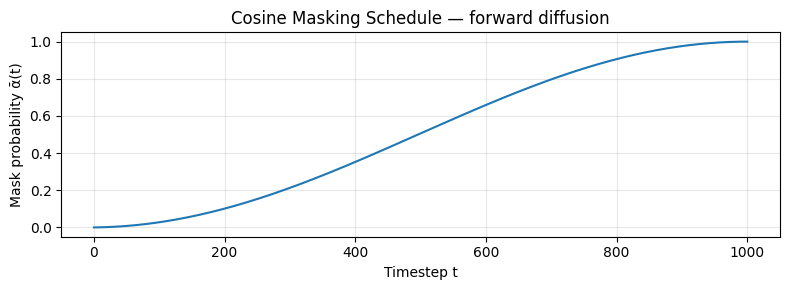

ᾱ at t=0: 0.0002 | t=T//2: 0.5062 | t=T: 1.0000


In [4]:
def cosine_mask_schedule(T: int, s: float = 0.008):
    """
    Cosine schedule for masking probability.
    alpha_bar[t] = P(token is MASKED at step t)
    alpha_bar[0] ≈ 0, alpha_bar[T] = 1
    """
    steps = T + 1
    t = torch.linspace(0, T, steps)
    # map to [0,1] masking prob via cosine
    alphas_bar = 1 - torch.cos(((t / T) + s) / (1 + s) * math.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar.max()  # normalize to [0, 1]
    return alphas_bar  # shape: (T+1,)


# Build schedule
alphas_bar = cosine_mask_schedule(cfg.T).to(DEVICE)

# Visualize
plt.figure(figsize=(8, 3))
plt.plot(alphas_bar.cpu().numpy())
plt.xlabel('Timestep t')
plt.ylabel('Mask probability ᾱ(t)')
plt.title('Cosine Masking Schedule — forward diffusion')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'ᾱ at t=0: {alphas_bar[0]:.4f} | t=T//2: {alphas_bar[cfg.T//2]:.4f} | t=T: {alphas_bar[-1]:.4f}')

## 4. Forward Diffusion Process

Given clean tokens $x_0$ and timestep $t$, sample noisy $x_t$:

$$x_t^i = \text{[MASK]} \text{ w.p. } \bar{\alpha}_t, \quad x_t^i = x_0^i \text{ otherwise}$$

In [31]:
def q_sample(x0: torch.Tensor, t: torch.Tensor, alphas_bar: torch.Tensor,
             mask_token_id: int) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Forward diffusion: corrupt x0 at timestep t.

    Args:
        x0:            (B, L) — clean token ids
        t:             (B,)   — timestep indices
        alphas_bar:    (T+1,) — masking probability schedule
        mask_token_id: int    — id of [MASK] token

    Returns:
        xt:      (B, L) — noisy token ids
        mask:    (B, L) — bool, True where token was masked
    """
    B, L = x0.shape
    # masking probability for each sample in the batch
    mask_prob = alphas_bar[t]  # (B,)
    mask_prob = mask_prob.unsqueeze(1).expand(B, L)  # (B, L)

    # sample binary mask
    mask = torch.bernoulli(mask_prob).bool()  # (B, L)

    xt = x0.clone()
    xt[mask] = mask_token_id
    return xt, mask


# Quick sanity check
x0_test = torch.randint(0, 1000, (4, cfg.seq_len))
t_test  = torch.tensor([0, 100, 500, 999])
xt_test, m_test = q_sample(x0_test, t_test, alphas_bar.cpu(), cfg.mask_token_id)
for i, tt in enumerate([0, 100, 500, 999]):
    frac = m_test[i].float().mean().item()
    print(f't={tt:4d} | masked fraction: {frac:.3f} | expected ≈ {alphas_bar[tt]:.3f}')

t=   0 | masked fraction: 0.000 | expected ≈ 0.000
t= 100 | masked fraction: 0.023 | expected ≈ 0.028
t= 500 | masked fraction: 0.500 | expected ≈ 0.506
t= 999 | masked fraction: 1.000 | expected ≈ 1.000


## 5. TransformerUNet Architecture

### Design
```
tokens (B, L) → embed → + time_embed
        ↓
   [Encoder scale 0]  L=64  → skip_0
        ↓ downsample (stride-2 conv1d)
   [Encoder scale 1]  L=32  → skip_1
        ↓ downsample
   [Encoder scale 2]  L=16  → skip_2
        ↓ downsample
   [Bottleneck]       L=8
        ↓ upsample (interpolate)
   [Decoder scale 2]  L=16  ← skip_2 (concat)
        ↓ upsample
   [Decoder scale 1]  L=32  ← skip_1
        ↓ upsample
   [Decoder scale 0]  L=64  ← skip_0
        ↓
   Linear → logits (B, L, V)
```

In [6]:
# ─── Sinusoidal Time Embedding ─────────────────────────────────────────────
class SinusoidalTimeEmbedding(nn.Module):
    """Encodes diffusion timestep t → vector of dim d_model."""
    def __init__(self, d_model: int):
        super().__init__()
        self.d_model = d_model
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.SiLU(),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """t: (B,) int → (B, d_model)"""
        half = self.d_model // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )  # (half,)
        # t: (B,) → (B, half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, d_model)
        return self.mlp(emb)  # (B, d_model)

In [7]:
# ─── Transformer Block (1D sequence) ──────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    Pre-LN Transformer block with time-step conditioning via AdaLayerNorm.
    Input: (B, L, d_model), time_emb: (B, d_model)
    """
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Multi-head self-attention
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )

        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

        # AdaLN: time embedding → scale + shift
        self.ada_ln_proj = nn.Linear(d_model, d_model * 2)  # → (scale, shift)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        """
        x:        (B, L, d_model)
        time_emb: (B, d_model)
        returns:  (B, L, d_model)
        """
        # AdaLN conditioning
        scale_shift = self.ada_ln_proj(time_emb)  # (B, 2*d_model)
        scale, shift = scale_shift.chunk(2, dim=-1)  # (B, d_model) each
        scale = scale.unsqueeze(1)   # (B, 1, d_model)
        shift = shift.unsqueeze(1)   # (B, 1, d_model)

        # Self-attention with pre-LN
        h = self.norm1(x) * (1 + scale) + shift
        attn_out, _ = self.attn(h, h, h)
        x = x + attn_out

        # FFN with pre-LN
        x = x + self.ff(self.norm2(x))
        return x

In [8]:
# ─── UNet Scale Modules ────────────────────────────────────────────────────
class UNetScale(nn.Module):
    """A single UNet scale: N TransformerBlocks."""
    def __init__(self, n_blocks: int, d_model: int, n_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_blocks)
        ])

    def forward(self, x, time_emb):
        for blk in self.blocks:
            x = blk(x, time_emb)
        return x


class Downsample1D(nn.Module):
    """Halve sequence length: (B, L, C) → (B, L//2, C') via strided conv."""
    def __init__(self, d_in: int, d_out: int):
        super().__init__()
        # conv1d operates on (B, C, L)
        self.conv = nn.Conv1d(d_in, d_out, kernel_size=3, stride=2, padding=1)
        self.norm = nn.LayerNorm(d_out)

    def forward(self, x):
        # x: (B, L, C)
        x = rearrange(x, 'b l c -> b c l')
        x = self.conv(x)
        x = rearrange(x, 'b c l -> b l c')
        return self.norm(x)


class Upsample1D(nn.Module):
    """Double sequence length: (B, L, C) → (B, 2L, C') via interpolation + conv."""
    def __init__(self, d_in: int, d_out: int):
        super().__init__()
        self.conv = nn.Conv1d(d_in, d_out, kernel_size=3, padding=1)
        self.norm = nn.LayerNorm(d_out)

    def forward(self, x):
        # x: (B, L, C)
        x = rearrange(x, 'b l c -> b c l')
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = self.conv(x)
        x = rearrange(x, 'b c l -> b l c')
        return self.norm(x)


class SkipFusion(nn.Module):
    """Gated blend instead of blind concat — prevents skip from dominating."""
    def __init__(self, d_model: int):
        super().__init__()
        self.proj  = nn.Linear(d_model * 2, d_model)
        # Learnable gate: starts at 0.5, learns how much skip to use
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x_up, x_skip):
        gate = torch.sigmoid(self.alpha)
        # Gated blend before projection
        fused = gate * x_skip + (1 - gate) * x_up
        # Also keep the full concat path for expressiveness
        return self.proj(torch.cat([x_up, fused], dim=-1))

In [9]:
# ─── TransformerUNet ───────────────────────────────────────────────────────
class TransformerUNet(nn.Module):
    """
    Diffusion denoising model for text.

    Given noisy tokens x_t and timestep t, predicts x_0 (the clean tokens).
    Architecture: UNet with Transformer blocks at each scale.

    Shape flow (n_scales=3, seq_len=64):
      Input        : (B, 64, D)
      enc_scales[0]: (B, 64, D)  → skip[0]  → downsample → (B, 32, D)
      enc_scales[1]: (B, 32, D)  → skip[1]  → downsample → (B, 16, D)
      enc_scales[2]: (B, 16, D)  → skip[2]  (NO downsample — last encoder)
      bottleneck   : (B, 16, D)
      dec_scales[0]: upsample → (B, 32, D) + skip[1] → process
      dec_scales[1]: upsample → (B, 64, D) + skip[0] → process
      dec_scales[2]: (B, 64, D) + skip[2 (last enc)] → process  ← NO upsample
      output       : (B, 64, V)
    """
    def __init__(self, cfg: Config):
        super().__init__()
        V = cfg.vocab_size
        D = cfg.d_model
        H = cfg.n_heads
        F = cfg.d_ff
        drop = cfg.dropout
        n_scales = len(cfg.encoder_layers)  # 3
        self.self_cond_embed = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.self_cond_gate  = nn.Parameter(torch.zeros(1))  # starts ignored
        # ── Embeddings ───────────────────────────────────────────────────
        self.token_embed = nn.Embedding(V, D)
        self.pos_embed   = nn.Embedding(cfg.seq_len, D)
        self.time_embed  = SinusoidalTimeEmbedding(D)
        self.embed_drop  = nn.Dropout(drop)

        # ── Encoder ──────────────────────────────────────────────────────
        # n_scales encoder blocks; downsample between all EXCEPT after last
        self.enc_scales  = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        for i, n_blk in enumerate(cfg.encoder_layers):
            self.enc_scales.append(UNetScale(n_blk, D, H, F, drop))
            if i < n_scales - 1:          # n_scales-1 downsamples total
                self.downsamples.append(Downsample1D(D, D))

        # ── Bottleneck ───────────────────────────────────────────────────
        self.bottleneck = UNetScale(cfg.bottleneck_layers, D, H, F, drop)

        # ── Decoder ──────────────────────────────────────────────────────
        # Mirror of encoder:
        #   dec_scales[0] → upsample first, then fuse skip from enc_scales[-2]
        #   dec_scales[1] → upsample,       fuse skip from enc_scales[-3] (= enc_scales[0])
        #   dec_scales[2] → NO upsample,    fuse skip from enc_scales[-1] (same length as bottleneck)
        #
        # In general: decoder scale i gets skip from encoder scale (n_scales-1-i).
        # Upsample happens for i = 0 .. n_scales-2  (all except the last decoder scale).
        self.dec_scales   = nn.ModuleList()
        self.upsamples    = nn.ModuleList()
        self.skip_fusions = nn.ModuleList()
        for i, n_blk in enumerate(cfg.decoder_layers):
            if i < n_scales - 1:          # upsample for all but the last decoder scale
                self.upsamples.append(Upsample1D(D, D))
            self.skip_fusions.append(SkipFusion(D))   # every decoder scale fuses a skip
            self.dec_scales.append(UNetScale(n_blk, D, H, F, drop))

        # ── Output head ──────────────────────────────────────────────────
        self.out_norm = nn.LayerNorm(D)
        self.out_proj = nn.Linear(D, V)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, xt: torch.Tensor, t: torch.Tensor, x_prev_pred=None) -> torch.Tensor:
        """
        xt: (B, L) — noisy token ids
        t:  (B,)   — diffusion timesteps
        returns logits: (B, L, V)
        """
        B, L = xt.shape
        n_scales = len(self.enc_scales)
        positions = torch.arange(L, device=xt.device).unsqueeze(0).expand(B, -1)

        # Embed tokens + positions
        x = self.token_embed(xt) + self.pos_embed(positions)  # (B, L, D)
        if x_prev_pred is not None:
          gate = torch.sigmoid(self.self_cond_gate)
          x = x + gate * self.self_cond_embed(x_prev_pred)
        x = self.embed_drop(x)

        # Time embedding
        time_emb = self.time_embed(t)  # (B, D)

        # ── Encoder ──────────────────────────────────────────────────────
        # skips[i] has length L >> (2**i)
        # skips[0]: L=64, skips[1]: L=32, skips[2]: L=16
        skips = []
        for i, enc in enumerate(self.enc_scales):
            x = enc(x, time_emb)
            skips.append(x)                    # save AFTER transformer, BEFORE downsample
            if i < len(self.downsamples):      # downsample between scales
                x = self.downsamples[i](x)

        # ── Bottleneck ───────────────────────────────────────────────────
        x = self.bottleneck(x, time_emb)       # still at smallest scale (L=16)

        # ── Decoder ──────────────────────────────────────────────────────
        #   bottleneck: L=16, fuse with skips[2] (L=16) — same length, just add
        #   upsample → L=32, fuse with skips[1]
        #   upsample → L=64, fuse with skips[0]
        up_idx = 0
        for i, (dec, fuse) in enumerate(zip(self.dec_scales, self.skip_fusions)):
            skip_idx = n_scales - 1 - i         # 2, 1, 0
            if i > 0:                            # upsample for i=1,2 (NOT i=0: same length as bottleneck)
                x = self.upsamples[up_idx](x)
                up_idx += 1
            x = fuse(x, skips[skip_idx])        # fuse skip connection
            x = dec(x, time_emb)

        # ── Output ───────────────────────────────────────────────────────
        x = self.out_norm(x)
        logits = self.out_proj(x)               # (B, L, V)
        return logits

    def count_params(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Total params:     {total:,}')
        print(f'Trainable params: {trainable:,}')
        return total

In [10]:
# Instantiate and inspect
model = TransformerUNet(cfg).to(DEVICE)
model.count_params()

# Forward pass sanity check
dummy_xt = torch.randint(0, cfg.vocab_size, (4, cfg.seq_len)).to(DEVICE)
dummy_t  = torch.randint(0, cfg.T, (4,)).to(DEVICE)
with torch.no_grad():
    dummy_logits = model(dummy_xt, dummy_t)
print(f'\nInput shape:  {dummy_xt.shape}')
print(f'Output shape: {dummy_logits.shape}  (B, L, V)')
assert dummy_logits.shape == (4, cfg.seq_len, cfg.vocab_size), "Shape mismatch!"
print('✅ Forward pass OK!')

Total params:     55,131,477
Trainable params: 55,131,477

Input shape:  torch.Size([4, 128])
Output shape: torch.Size([4, 128, 50257])  (B, L, V)
✅ Forward pass OK!


## 6. Training Objective

The training loss is **cross-entropy only over masked positions**:

$$\mathcal{L} = -\mathbb{E}_{t, x_0, x_t} \left[ \sum_{i \in \text{masked}} \log p_\theta(x_0^i \mid x_t, t) \right]$$

The model learns to predict the **original token** at each masked position, conditioned on all visible tokens and the timestep.

```markdown
────────────────────────────────────────────────────────────────────
FUNCTION  diffusion_loss(model, x0, alphas_bar, cfg)
────────────────────────────────────────────────────────────────────

INPUT:
  model       : TransformerUNet — takes (x_t, t, x_prev?) → logits
  x0          : (B, L)   clean token ids from the dataset
  alphas_bar  : (T+1,)   precomputed cosine masking schedule
                          alphas_bar[t] = P(token masked at step t)
  cfg         : Config   hyperparameters

────────────────────────────────────────────────────────────────────
STEP 1 — Sample timesteps
────────────────────────────────────────────────────────────────────

  t ← sample_timesteps_weighted(B, T)
      # shape: (B,)  each value in [1, T]
      # 50% from [1, T//4]  ← easier, cleaner gradients
      # 50% from [1, T]     ← full range for generalization

  WHY NOT t=0?
    alphas_bar[0] ≈ 0.0  →  zero masks  →  zero loss  →  zero gradient
    useless step, skip it

────────────────────────────────────────────────────────────────────
STEP 2 — Forward diffusion: corrupt x0 → x_t
────────────────────────────────────────────────────────────────────

  mask_prob ← alphas_bar[t]          # (B,) — one prob per sample
  mask_prob ← expand to (B, L)       # broadcast over sequence

  mask ← Bernoulli(mask_prob)        # (B, L) bool
          # each token independently flipped to [MASK] w.p. mask_prob

  x_t ← copy of x0
  x_t[mask] ← MASK_TOKEN_ID          # replace masked positions

  CONCRETE EXAMPLE  (B=1, L=8, t=500, ᾱ_500≈0.50):
    x0    = [the, cat, sat, on,   the, mat, eos, pad]
    mask  = [  0,   1,   0,  1,     0,   1,   0,   0]
    x_t   = [the, MSK, sat, MSK, the, MSK, eos, pad]

────────────────────────────────────────────────────────────────────
STEP 3 — Self-conditioning (50% of training steps)
────────────────────────────────────────────────────────────────────

  x_prev ← None

  IF rand() < 0.5:
    WITH no_grad():                   # don't backprop through this
      logits_prev ← model(x_t, t, cond=None)   # (B, L, V)
      x_prev      ← argmax(logits_prev, dim=-1) # (B, L)  rough guess

    # x_prev is now a noisy estimate of x0
    # The main forward pass gets to see this hint

  WHY no_grad()?
    This is just a "hint" input, not part of the loss graph.
    Backpropping through it doubles memory and adds unstable gradients.

────────────────────────────────────────────────────────────────────
STEP 4 — Model forward pass
────────────────────────────────────────────────────────────────────

  logits ← model(x_t, t, cond=x_prev)    # (B, L, V)

  WHAT THE MODEL SEES:
    x_t      — partially masked sequence (context clues)
    t        — how noisy is this? (via sinusoidal + AdaLN)
    x_prev   — my own previous rough guess (optional hint)

  WHAT THE MODEL OUTPUTS:
    logits[b, i, v] = unnormalized score for token v
                      at position i in sample b

────────────────────────────────────────────────────────────────────
STEP 5 — Compute loss ONLY on masked positions
────────────────────────────────────────────────────────────────────

  logits_flat  ← reshape logits  (B, L, V) → (B*L, V)
  targets_flat ← reshape x0      (B, L)    → (B*L,)
  mask_flat    ← reshape mask    (B, L)    → (B*L,)  bool

  # Select only the destroyed positions
  logits_masked  ← logits_flat[mask_flat]    # (M, V)  M = num masked
  targets_masked ← targets_flat[mask_flat]   # (M,)

  loss ← CrossEntropyLoss(logits_masked, targets_masked, reduction='mean')

  WHAT CROSS ENTROPY DOES HERE:
    For each masked position i:
      p_i = softmax(logits_masked[i])          # prob over vocab
      ce_i = -log(p_i[targets_masked[i]])      # how wrong were we?

    loss = mean(ce_i  for all i in masked positions)

  EDGE CASE — what if no tokens were masked?
    Happens when t is very small (t≈1, ᾱ≈0.001)
    mask_flat.sum() == 0  →  return loss=0, skip update
    (extremely rare with importance weighting)

────────────────────────────────────────────────────────────────────
OUTPUT:
  loss    : scalar  — backprop through this
  n_masked: int     — how many positions contributed (for logging)
────────────────────────────────────────────────────────────────────

In [11]:
def sample_timesteps(B, T, device, low_t_bias=0.5):
    """
    Sample t with bias toward low timesteps where gradients are informative.
    low_t_bias=0.5 means half the batch uses t in [1, T//4].
    """
    if torch.rand(1) < low_t_bias:
        t = torch.randint(1, T // 4 + 1, (B,), device=device)
    else:
        t = torch.randint(1, T + 1, (B,), device=device)
    return t


## 7. Dataset — TinyStories

In [12]:
class TextDataset(Dataset):
    """
    Chunks a token stream into fixed-length sequences.
    """
    def __init__(self, token_ids: torch.Tensor, seq_len: int):
        self.seq_len = seq_len
        # Trim to multiple of seq_len
        n = (len(token_ids) // seq_len) * seq_len
        self.data = token_ids[:n].reshape(-1, seq_len)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)
tokenizer.pad_token = tokenizer.eos_token

# Load TinyStories
print('Loading TinyStories...')
raw = load_dataset('roneneldan/TinyStories', split='train')[:30000]
text = ' '.join(raw['text'])

# Tokenize
print('Tokenizing...')
token_ids = tokenizer.encode(text, return_tensors='pt').squeeze()
print(f'Total tokens: {len(token_ids):,}')

# Build dataset
train_ds = TextDataset(token_ids, cfg.seq_len)
train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                      num_workers=0, pin_memory=False)

print(f'Dataset: {len(train_ds):,} sequences × {cfg.seq_len} tokens')
print(f'Batches per epoch: {len(train_dl):,}')

Loading TinyStories...
Tokenizing...


Token indices sequence length is longer than the specified maximum sequence length for this model (6607097 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 6,607,097
Dataset: 51,617 sequences × 128 tokens
Batches per epoch: 1,614


## 8. Optimizer, LR Schedule & Training Loop

In [13]:
def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / max(1, warmup_steps)
        progress = float(current_step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    betas=(0.9, 0.999),
    weight_decay=0.01
)

total_steps = min(cfg.max_steps, cfg.n_epochs * len(train_dl))
scheduler   = get_cosine_schedule_with_warmup(optimizer, cfg.warmup_steps, total_steps)

print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps:         {cfg.warmup_steps}')

Total training steps: 30,000
Warmup steps:         500


In [14]:
# ─── Training Loop ─────────────────────────────────────────────────────────
train_losses = []
global_step  = 0

model.train()
print('Starting training...\n')

for epoch in range(cfg.n_epochs):
    epoch_loss = 0.0
    n_batches  = 0
    pbar = tqdm(train_dl, desc=f'Epoch {epoch+1}/{cfg.n_epochs}', leave=True)

    for batch in pbar:
        if global_step >= cfg.max_steps:
            break

        x0 = batch.to(DEVICE)  # (B, L)

        optimizer.zero_grad()
        loss, n_masked = diffusion_loss(model, x0, alphas_bar, cfg)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        epoch_loss += loss_val
        n_batches  += 1
        global_step += 1

        train_losses.append(loss_val)
        lr_now = scheduler.get_last_lr()[0]
        pbar.set_postfix(loss=f'{loss_val:.4f}', lr=f'{lr_now:.2e}',
                         masked=int(n_masked))

    avg = epoch_loss / max(n_batches, 1)
    print(f'Epoch {epoch+1} avg loss: {avg:.4f} | steps: {global_step}')

    if global_step >= cfg.max_steps:
        print('Reached max_steps, stopping.')
        break

print('Training complete!')

Starting training...



Epoch 1/30:   0%|          | 0/1614 [00:00<?, ?it/s]

Epoch 1 avg loss: 6.5098 | steps: 1614


Epoch 2/30:   0%|          | 0/1614 [00:00<?, ?it/s]

Epoch 2 avg loss: 5.9657 | steps: 3228


...

Epoch 4 avg loss: 5.9170 | steps: 6456


Epoch 5/30:   0%|          | 0/1614 [00:00<?, ?it/s]

Epoch 5 avg loss: 5.9132 | steps: 8070


Epoch 6/30:   0%|          | 0/1614 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9. Training Curve

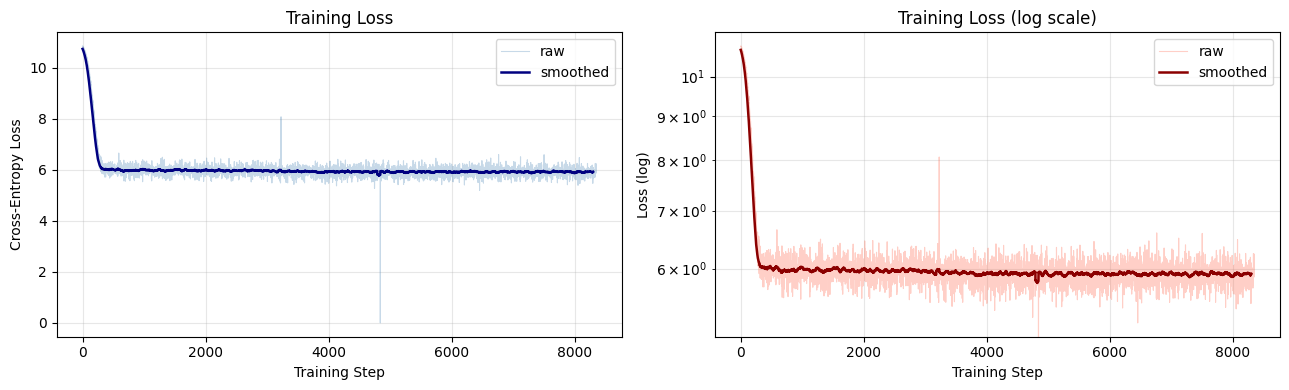

Final loss: 5.9148 | Min loss: 0.0000


In [15]:
# Smooth and plot the training loss
def smooth(y, w=50):
    return np.convolve(y, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw loss
axes[0].plot(train_losses, alpha=0.3, color='steelblue', linewidth=0.8, label='raw')
if len(train_losses) > 50:
    axes[0].plot(smooth(train_losses), color='navy', linewidth=1.8, label='smoothed')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss in log scale
axes[1].semilogy(train_losses, alpha=0.3, color='tomato', linewidth=0.8, label='raw')
if len(train_losses) > 50:
    axes[1].semilogy(smooth(train_losses), color='darkred', linewidth=1.8, label='smoothed')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Training Loss (log scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(f'Final loss: {train_losses[-1]:.4f} | Min loss: {min(train_losses):.4f}')

## 10. Reverse Diffusion — Sampling

At inference, we start with **all tokens masked** and iteratively denoise:

1. Start: $x_T = [\text{MASK}]^L$
2. For $t = T, T-1, \ldots, 1$:
   - Get logits $p_\theta(x_0 | x_t, t)$
   - Sample candidate tokens from the logits
   - **Re-mask** tokens with probability $\bar{\alpha}_{t-1}$ (anneal the noise)
   - Keep confident (low-entropy) predictions unmasked
3. Output $x_0$

In [16]:
@torch.no_grad()
def sample(
    model: TransformerUNet,
    cfg: Config,
    alphas_bar: torch.Tensor,
    n_samples: int = 4,
    n_steps: int = None,
    temperature: float = 1.0,
    top_k: int = 50,
    verbose: bool = False,
) -> torch.Tensor:
    """
    Ancestral sampling from the diffusion SLM.

    Returns:
        tokens: (n_samples, L) — generated token ids
    """
    model.eval()
    n_steps = n_steps or cfg.n_steps_inf
    L = cfg.seq_len
    device = next(model.parameters()).device

    # Timestep schedule for inference (uniform spacing)
    t_seq = torch.linspace(cfg.T, 1, n_steps).long()

    # Start from fully masked sequence
    x = torch.full((n_samples, L), cfg.mask_token_id, dtype=torch.long, device=device)

    for i, t_val in enumerate(t_seq):
        t_prev = t_seq[i + 1] if i + 1 < len(t_seq) else torch.tensor(0)
        t_batch = t_val.expand(n_samples).to(device)

        # Predict clean tokens
        logits = model(x, t_batch)  # (B, L, V)

        # Temperature scaling
        logits = logits / temperature

        # Top-k filtering
        if top_k > 0:
            v, _ = torch.topk(logits, top_k, dim=-1)
            logits[logits < v[..., -1:]] = float('-inf')

        # Sample from posterior
        probs = F.softmax(logits, dim=-1)  # (B, L, V)
        x_pred = torch.multinomial(
            probs.reshape(-1, cfg.vocab_size),
            num_samples=1
        ).reshape(n_samples, L)  # (B, L)

        # Masking rate at t_prev
        mask_prob_prev = alphas_bar[t_prev.item() if t_prev.dim() == 0 else t_prev[0].item()]

        # Confidence-based unmasking: keep tokens where model is confident
        # Entropy of predictions (lower = more confident)
        entropy = -(probs * (probs + 1e-9).log()).sum(-1)  # (B, L)
        max_entropy = math.log(cfg.vocab_size)
        confidence = 1.0 - entropy / max_entropy  # (B, L), high = confident

        # Re-mask tokens stochastically, biased by confidence
        remask_prob = mask_prob_prev * (1.0 - confidence * 0.5)  # modulate by confidence
        remask = torch.bernoulli(remask_prob.clamp(0, 1)).bool()

        # Update: use prediction, then re-mask uncertain tokens
        x = x_pred
        x[remask] = cfg.mask_token_id

        if verbose and (i % (n_steps // 5) == 0):
            n_masked = (x == cfg.mask_token_id).float().mean().item()
            print(f'  Step {i+1:3d}/{n_steps} | t={t_val.item():4d} | masked: {n_masked:.3f}')

    return x


print('Sampling function defined.')

Sampling function defined.


In [17]:
# Generate samples
print('Generating samples...\n')
generated = sample(
    model, cfg, alphas_bar,
    n_samples=4,
    n_steps=cfg.n_steps_inf,
    temperature=0.9,
    top_k=50,
    verbose=True
)

print('\n' + '='*60)
print('GENERATED SAMPLES')
print('='*60)
for i, seq in enumerate(generated):
    # Replace mask tokens with <MASK> in decode
    ids = seq.tolist()
    text = tokenizer.decode([tok for tok in ids if tok != cfg.mask_token_id],
                             skip_special_tokens=True)
    remaining_masks = ids.count(cfg.mask_token_id)
    print(f'\n[Sample {i+1}] (remaining masks: {remaining_masks})')
    print(text[:300])

Generating samples...

  Step   1/50 | t=1000 | masked: 0.646
  Step  11/50 | t= 796 | masked: 0.570
  Step  21/50 | t= 592 | masked: 0.436
  Step  31/50 | t= 388 | masked: 0.182
  Step  41/50 | t= 184 | masked: 0.062

GENERATED SAMPLES

[Sample 1] (remaining masks: 0)
 " They with. you the it
. They and. I and. it and can the to and to they," and have
. I
 I
.,
 the the and". they
. you
 says to.., on and's.!". it you,". " to Ben and.

. the
 are can, the the. says!" "...,.. the Tom
 They them..." the He. and to.." was
..
 " and says on They
 a, and
. says. Anna 

[Sample 2] (remaining masks: 0)
 the are

. said Ben Tom the. says it
 their. Anna go,. to. Ben to is, you have. their... they
 They, They Mom They not Anna " They You have He They, and Lily. Lily a Anna said
 of have Ben will He a. it. They
.They. is
 the.". is their the They ". a. to to their to Tom Ben," the with Ben. with was


[Sample 3] (remaining masks: 0)
 a you......
 was to are play the a a They not Ben their
.,.
 

## 11. Conditional Generation (Prefix Infilling)

A key advantage of diffusion LMs: **arbitrary conditioning**. Given a prefix, fill in the rest.

In [26]:
@torch.no_grad()
def infill(
    model: TransformerUNet,
    cfg: Config,
    alphas_bar: torch.Tensor,
    prefix: str,
    n_steps: int = 40,
    temperature: float = 1.0,
) -> str:
    """
    Given a prefix string, complete the sequence.
    """
    model.eval()
    device = next(model.parameters()).device
    L = cfg.seq_len

    # Tokenize prefix
    prefix_ids = tokenizer.encode(prefix)
    prefix_len = min(len(prefix_ids), L)
    prefix_ids = prefix_ids[:prefix_len]

    # Build initial x: prefix + MASK tokens
    x = torch.full((1, L), cfg.mask_token_id, dtype=torch.long, device=device)
    x[0, :prefix_len] = torch.tensor(prefix_ids, device=device)

    # Mask indicating which positions are FIXED (prefix)
    fixed = torch.zeros(1, L, dtype=torch.bool, device=device)
    fixed[0, :prefix_len] = True

    t_seq = torch.linspace(cfg.T, 1, n_steps).long()

    for i, t_val in enumerate(t_seq):
        t_prev = t_seq[i + 1] if i + 1 < len(t_seq) else torch.tensor(0)
        t_batch = t_val.unsqueeze(0).to(device)

        logits = model(x, t_batch)  # (1, L, V)
        logits = logits / temperature

        probs = F.softmax(logits, dim=-1)
        x_pred = torch.multinomial(
            probs.reshape(-1, cfg.vocab_size), 1
        ).reshape(1, L)

        # Re-mask non-fixed positions
        mask_prob_prev = alphas_bar[t_prev.item() if t_prev.dim()==0 else 0].item()
        entropy = -(probs * (probs + 1e-9).log()).sum(-1)
        confidence = 1.0 - entropy / math.log(cfg.vocab_size)
        remask_prob = mask_prob_prev * (1.0 - confidence * 0.5)
        remask = torch.bernoulli(remask_prob.clamp(0,1)).bool()

        x = x_pred
        x[remask & ~fixed] = cfg.mask_token_id  # only remask non-fixed positions
        x[fixed] = torch.tensor(prefix_ids + [cfg.mask_token_id]*(prefix_len-len(prefix_ids)),
                                device=device)[:prefix_len]  # restore prefix always

    result = tokenizer.decode(
        [t for t in x[0].tolist() if t != cfg.mask_token_id],
        skip_special_tokens=True
    )
    return result


# Test infilling
prefixes = [
    "The story of",
    "In the year 1900, a little boy",
    "Science is the ",
]

print('CONDITIONAL GENERATION (PREFIX INFILLING)')
print('='*60)
for p in prefixes:
    result = infill(model, cfg, alphas_bar, p, n_steps=30, temperature=0.85)
    print(f'\nPrefix: "{p}"')
    print(f'Output: {result}')

CONDITIONAL GENERATION (PREFIX INFILLING)

Prefix: "The story of"
Output: The story of They They play and are a turned scared is OnceOkay likes the." them and They
!"
 could the will to. ball is here she and the and thing too They to They I Mom the can. You. and cozy. ball " her, kitchen take mistake
. "ily and.. and says the very
 on back He curious playing dog. sorry.."?".., hurt
 the
 small tomorrow in saw, said,. on and nice should to man Tom go not and. the She happy,Hello
. to They and it. and she look The Ben and They the castle.

Prefix: "In the year 1900, a little boy"
Output: In the year 1900, a little boy Ben he mom them water,. to to,?" theThe out What. a to switch you and leaf is having mom she
 She. momThe and, a goodbye. with a Anna

 the a talking good they when the very will and!" a also the blowing and to

 a to was glad and. " and for the She they see
arre driver earsIt the
 a to the need that You He. could it let.
 " down" to Mom.
 in was happy and. her Let. was
! p

## 12. Visualize the Denoising Process

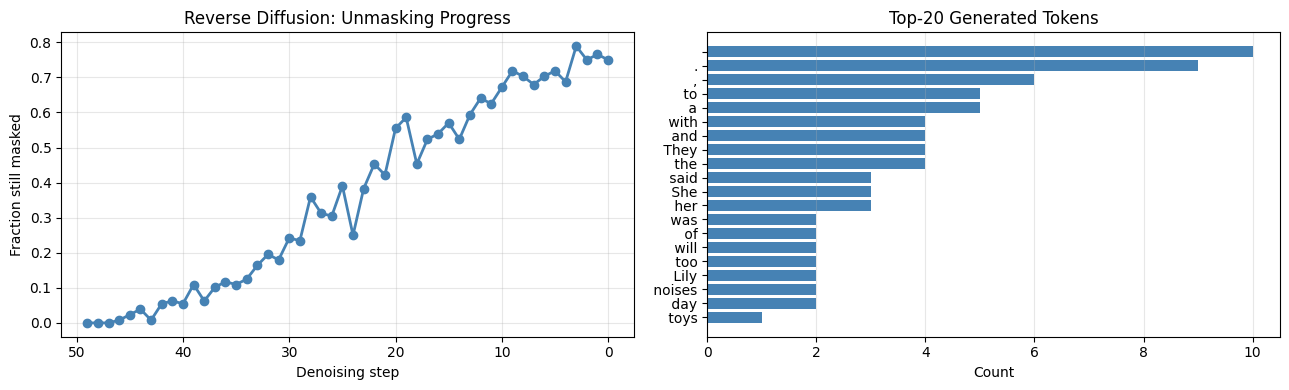

In [27]:
@torch.no_grad()
def visualize_denoising(model, cfg, alphas_bar, n_steps=20):
    """Show token predictions at each denoising step."""
    model.eval()
    device = next(model.parameters()).device
    L = cfg.seq_len

    x = torch.full((1, L), cfg.mask_token_id, dtype=torch.long, device=device)
    t_seq = torch.linspace(cfg.T, 1, n_steps).long()

    mask_fracs = []
    step_labels = []

    for i, t_val in enumerate(t_seq):
        t_prev = t_seq[i+1] if i+1 < len(t_seq) else torch.tensor(0)
        t_batch = t_val.unsqueeze(0).to(device)

        logits = model(x, t_batch)
        probs   = F.softmax(logits / 0.9, dim=-1)
        x_pred  = torch.multinomial(probs.reshape(-1, cfg.vocab_size), 1).reshape(1, L)

        mask_prob_prev = alphas_bar[t_prev.item() if t_prev.dim()==0 else 0].item()
        entropy    = -(probs * (probs + 1e-9).log()).sum(-1)
        confidence = 1.0 - entropy / math.log(cfg.vocab_size)
        remask_prob = (mask_prob_prev * (1.0 - confidence * 0.5)).clamp(0, 1)
        remask = torch.bernoulli(remask_prob).bool()

        x = x_pred
        x[remask] = cfg.mask_token_id

        frac = (x == cfg.mask_token_id).float().mean().item()
        mask_fracs.append(frac)
        step_labels.append(t_val.item())

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Masked fraction over time
    axes[0].plot(list(range(n_steps)), mask_fracs, 'o-', color='steelblue', linewidth=2)
    axes[0].set_xlabel('Denoising step')
    axes[0].set_ylabel('Fraction still masked')
    axes[0].set_title('Reverse Diffusion: Unmasking Progress')
    axes[0].invert_xaxis()
    axes[0].grid(True, alpha=0.3)

    # Final token distribution (top-20 token ids)
    token_ids = x[0].cpu().numpy()
    valid_ids = token_ids[token_ids != cfg.mask_token_id]
    unique, counts = np.unique(valid_ids, return_counts=True)
    top_idx = np.argsort(counts)[-20:]
    axes[1].barh([tokenizer.decode([int(u)]) for u in unique[top_idx]],
                 counts[top_idx], color='steelblue')
    axes[1].set_xlabel('Count')
    axes[1].set_title('Top-20 Generated Tokens')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()


visualize_denoising(model, cfg, alphas_bar, n_steps=cfg.n_steps_inf)

## 13. Model Checkpoint Save/Load

In [28]:
import os

# Save checkpoint
checkpoint = {
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'config': vars(cfg),
    'train_losses': train_losses,
    'global_step': global_step,
    'alphas_bar': alphas_bar.cpu(),
}
ckpt_path = 'diffusion_slm_checkpoint.pt'
torch.save(checkpoint, ckpt_path)
size_mb = os.path.getsize(ckpt_path) / 1e6
print(f'Checkpoint saved: {ckpt_path} ({size_mb:.1f} MB)')

# Load checkpoint (example)
def load_checkpoint(path, cfg, device):
    ckpt = torch.load(path, map_location=device)
    m = TransformerUNet(cfg).to(device)
    m.load_state_dict(ckpt['model_state'])
    ab = ckpt['alphas_bar'].to(device)
    print(f'Loaded checkpoint from step {ckpt["global_step"]} | final loss {ckpt["train_losses"][-1]:.4f}')
    return m, ab

# model, alphas_bar = load_checkpoint(ckpt_path, cfg, DEVICE)  # uncomment to reload

Checkpoint saved: diffusion_slm_checkpoint.pt (662.0 MB)


## 14. Architecture Summary & Extensions

### What we built

| Component | Details |
|---|---|
| **Diffusion type** | Masked Diffusion LM (MDLM) |
| **Forward process** | Cosine masking schedule |
| **Architecture** | TransformerUNet (3-scale encoder/decoder) |
| **Time conditioning** | Sinusoidal + AdaLayerNorm in every block |
| **Skip connections** | Concat + project at each decoder scale |
| **Training objective** | Cross-entropy on masked positions |
| **Sampling** | Confidence-based iterative unmasking |
| **Conditioning** | Prefix infilling (fixed tokens) |

### Scaling Up (LLaDA-style)
To scale this to a production dLM:
1. **Larger vocab/model**: 1B+ params, 32k vocab
2. **RoPE positional embeddings** instead of learned
3. **Flash Attention** for long sequences
4. **Absorbing diffusion** (SEDD) for better perplexity
5. **Self-conditioning**: pass previous prediction $\hat{x}_0$ back as input
6. **Hybrid AR+Diffusion** (MDLM + GPT) for speed

### Advantages over AR LLMs
- ✅ Parallel generation (faster at inference)
- ✅ Bidirectional context (better for understanding)
- ✅ Flexible conditioning (fill any span, not just prefix)
- ✅ No reversal curse
- ❌ More training steps needed
- ❌ Multi-step inference vs single-pass AR

In [21]:
# Final summary
total = sum(p.numel() for p in model.parameters())
print('='*55)
print('   DIFFUSION SLM — TransformerUNet Summary')
print('='*55)
print(f'  Vocab size:         {cfg.vocab_size:,}')
print(f'  Sequence length:    {cfg.seq_len}')
print(f'  d_model:            {cfg.d_model}')
print(f'  n_heads:            {cfg.n_heads}')
print(f'  UNet scales:        {len(cfg.encoder_layers)}')
print(f'  Total parameters:   {total:,}')
print(f'  Diffusion steps T:  {cfg.T}')
print(f'  Inference steps:    {cfg.n_steps_inf}')
print(f'  Training steps:     {global_step:,}')
print(f'  Final loss:         {train_losses[-1]:.4f}')
print('='*55)

   DIFFUSION SLM — TransformerUNet Summary
  Vocab size:         50,257
  Sequence length:    128
  d_model:            256
  n_heads:            8
  UNet scales:        3
  Total parameters:   55,131,477
  Diffusion steps T:  1000
  Inference steps:    50
  Training steps:     8,352
  Final loss:         5.9148
